In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [33]:
df=pd.read_csv(r"C:\Users\Reddy Sai Abhiram\OneDrive\Desktop\dv.csv")
df

,name,planet_status,mass,mass_error_min,mass_error_max,mass_sini,mass_sini_error_min,mass_sini_error_max,radius,radius_error_min
0,109 Psc b,Confirmed,5.743,0.28900,1.01100,6.38300,0.07800,0.07800,1.152,NaN
1,112 Psc b,Confirmed,NaN,0.00500,0.00400,0.03300,0.00500,0.00400,NaN,NaN
2,112 Psc c,Confirmed,9.866,1.78100,3.19000,NaN,NaN,NaN,NaN,NaN
3,11 UMi b,Confirmed,NaN,1.10000,1.10000,11.08730,1.10000,1.10000,NaN,NaN
4,14 And Ab,Confirmed,NaN,0.23000,0.23000,4.68400,0.23000,0.23000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
5981,YBP 401 b,Confirmed,NaN,0.05000,0.05000,0.46000,0.05000,0.05000,NaN,NaN
5982,YSES 2 b,Confirmed,6.300,0.90000,1.60000,NaN,NaN,NaN,NaN,NaN
5983,YZ Cet b,Confirmed,NaN,0.00028,0.00028,0.00220,0.00028,0.00028,NaN,NaN
5984,YZ Cet c,Confirmed,NaN,0.00035,0.00035,0.00359,0.00035,0.00035,NaN,NaN


Dataset Shape: (5986, 10)

Column Names:
Index(['name', 'planet_status', 'mass', 'mass_error_min', 'mass_error_max',
       'mass_sini', 'mass_sini_error_min', 'mass_sini_error_max', 'radius',
       'radius_error_min'],
      dtype='object')

Missing Values:
name                      0
planet_status             0
mass                   3907
mass_error_min         3169
mass_error_max         3169
mass_sini              4784
mass_sini_error_min    4947
mass_sini_error_max    4947
radius                 1418
radius_error_min       1893
dtype: int64


In [22]:
# Convert mass and radius to numeric values
df["mass"] = pd.to_numeric(df["mass"], errors="coerce")
df["radius"] = pd.to_numeric(df["radius"], errors="coerce")

# Remove rows where mass or radius is missing
mass_df = df.dropna(subset=["mass"])
radius_df = df.dropna(subset=["radius"])

print("Records with valid mass:", len(mass_df))
print("Records with valid radius:", len(radius_df))

Records with valid mass: 2079
Records with valid radius: 4568


In [23]:
# Highest mass planet
highest_mass_planet = mass_df.loc[mass_df["mass"].idxmax()]

# Lowest mass planet
lowest_mass_planet = mass_df.loc[mass_df["mass"].idxmin()]

# Average mass
average_mass = mass_df["mass"].mean()

# Average radius
average_radius = radius_df["radius"].mean()

print("Highest Mass Planet:")
print(highest_mass_planet[["name", "mass"]])

print("\nLowest Mass Planet:")
print(lowest_mass_planet[["name", "mass"]])

print("\nAverage Mass:", average_mass)
print("Average Radius:", average_radius)

Highest Mass Planet:
name    GJ 2030 Ac
mass        12.934
Name: 199, dtype: object

Lowest Mass Planet:
name    LHS 1678 b
mass       0.00019
Name: 4808, dtype: object

Average Mass: 1.4925384754050022
Average Radius: 0.4015150366243433


In [24]:
print("=" * 50)
print("          PLANET DATA ANALYSIS")
print("=" * 50)

print(f"Highest Mass Planet : {highest_mass_planet['name']}")
print(f"Highest Mass        : {highest_mass_planet['mass']}")

print(f"\nLowest Mass Planet  : {lowest_mass_planet['name']}")
print(f"Lowest Mass         : {lowest_mass_planet['mass']}")

print(f"\nAverage Planet Mass : {average_mass:.4f}")
print(f"Average Planet Radius: {average_radius:.4f}")

print("=" * 50)

          PLANET DATA ANALYSIS
Highest Mass Planet : GJ 2030 Ac
Highest Mass        : 12.934

Lowest Mass Planet  : LHS 1678 b
Lowest Mass         : 0.00019

Average Planet Mass : 1.4925
Average Planet Radius: 0.4015


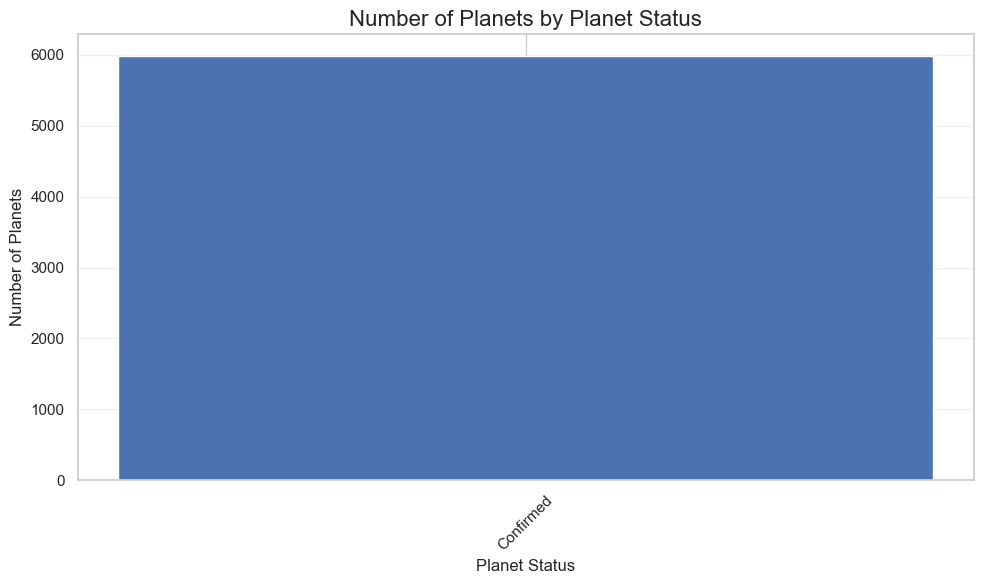

In [25]:
status_counts = df["planet_status"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(status_counts.index, status_counts.values)

plt.title("Number of Planets by Planet Status", fontsize=16)
plt.xlabel("Planet Status", fontsize=12)
plt.ylabel("Number of Planets", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

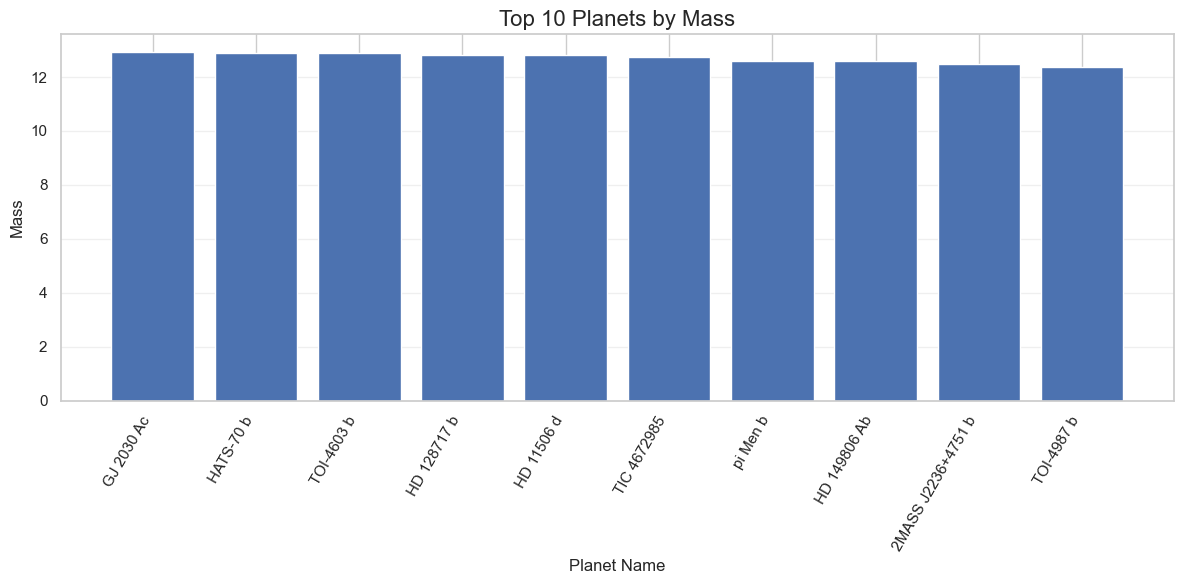

In [26]:
top10_mass = mass_df.sort_values(
    by="mass", 
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(top10_mass["name"], top10_mass["mass"])

plt.title("Top 10 Planets by Mass", fontsize=16)
plt.xlabel("Planet Name", fontsize=12)
plt.ylabel("Mass", fontsize=12)

plt.xticks(rotation=60, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

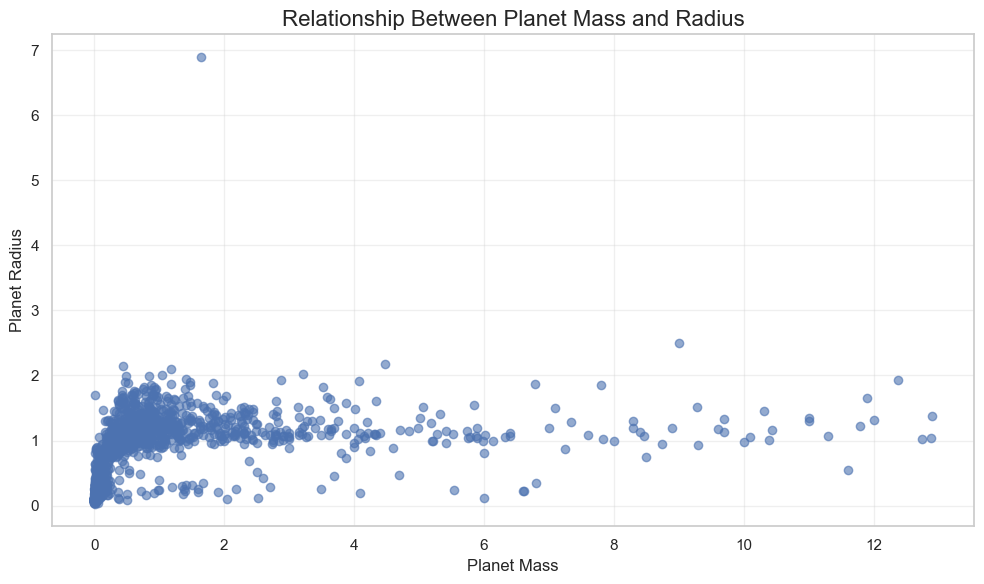

In [27]:
scatter_df = df.dropna(subset=["mass", "radius"])

plt.figure(figsize=(10, 6))

plt.scatter(
    scatter_df["mass"],
    scatter_df["radius"],
    alpha=0.6
)

plt.title("Relationship Between Planet Mass and Radius", fontsize=16)
plt.xlabel("Planet Mass", fontsize=12)
plt.ylabel("Planet Radius", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

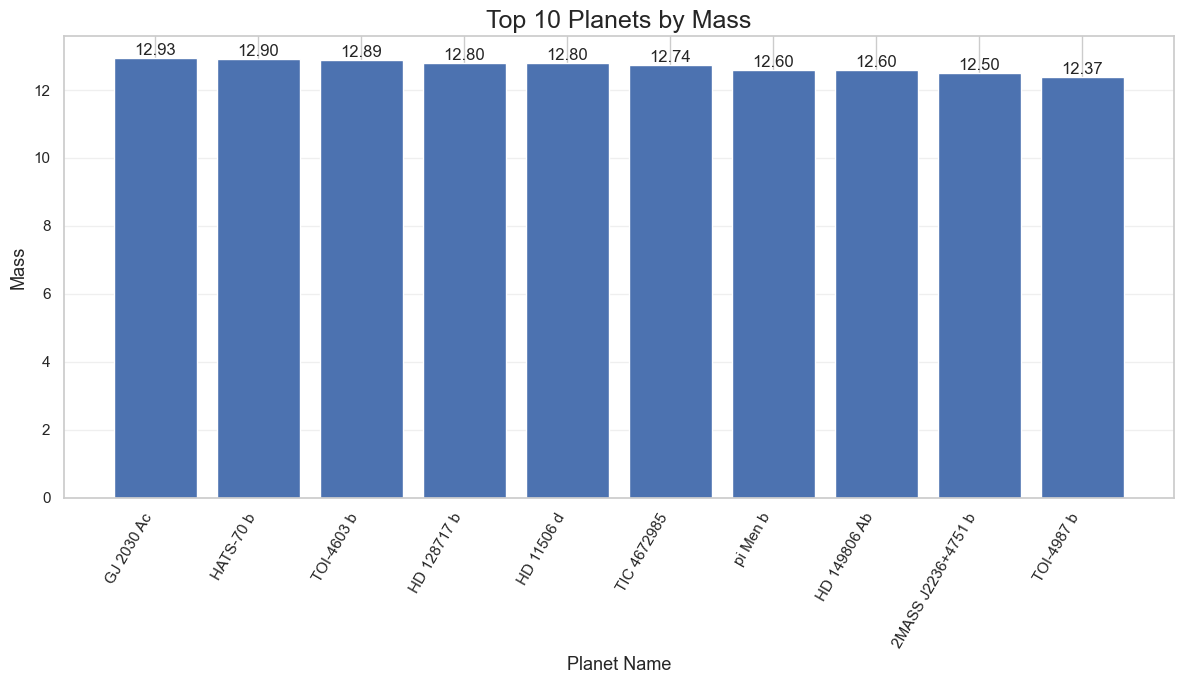

In [28]:
plt.figure(figsize=(12, 7))

bars = plt.bar(
    top10_mass["name"],
    top10_mass["mass"]
)

plt.title("Top 10 Planets by Mass", fontsize=18)
plt.xlabel("Planet Name", fontsize=13)
plt.ylabel("Mass", fontsize=13)

plt.xticks(rotation=60, ha="right")

# Display values above bars
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
summary = pd.DataFrame({
    "Metric": [
        "Highest Mass Planet",
        "Highest Mass",
        "Lowest Mass Planet",
        "Lowest Mass",
        "Average Mass",
        "Average Radius"
    ],
    "Value": [
        highest_mass_planet["name"],
        highest_mass_planet["mass"],
        lowest_mass_planet["name"],
        lowest_mass_planet["mass"],
        average_mass,
        average_radius
    ]
})

summary.to_csv(
    "Planet_Analysis_Summary.csv",
    index=False
)

summary

,Metric,Value
0,Highest Mass Planet,GJ 2030 Ac
1,Highest Mass,12.934
2,Lowest Mass Planet,LHS 1678 b
3,Lowest Mass,0.00019
4,Average Mass,1.492538
5,Average Radius,0.401515


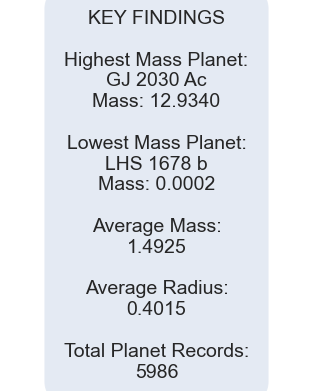

In [31]:
ax4 = plt.subplot(2, 2, 4)

ax4.axis("off")

key_findings = (
    "KEY FINDINGS\n\n"
    f"Highest Mass Planet:\n"
    f"{highest_mass_planet['name']}\n"
    f"Mass: {highest_mass_planet['mass']:.4f}\n\n"
    
    f"Lowest Mass Planet:\n"
    f"{lowest_mass_planet['name']}\n"
    f"Mass: {lowest_mass_planet['mass']:.4f}\n\n"
    
    f"Average Mass:\n"
    f"{average_mass:.4f}\n\n"
    
    f"Average Radius:\n"
    f"{average_radius:.4f}\n\n"
    
    f"Total Planet Records:\n"
    f"{len(df)}"
)

ax4.text(
    0.5,
    0.5,
    key_findings,
    ha="center",
    va="center",
    fontsize=14,
    bbox=dict(
        boxstyle="round,pad=1",
        alpha=0.15
    )
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()